In [1]:
from models.analyzer import FeatureSelectionAnalyzer

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [4]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [5]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [6]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре'
]

In [7]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        pass 

In [8]:
for col in category_cols:
    data[col] = data[col].fillna('missing').astype('str')
    data[col] = data[col].astype('category')

In [9]:
data = data[cols]

NameError: name 'cols' is not defined

In [10]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [11]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [12]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [14]:
cat_features

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид_STEMI',
 'Инфаркт-зависимая_артерия',
 'Поражение_ствола',
 'Инфаркт_миокарда_в_анамнезе_lt_3',
 'Инфаркт_миокарда_в_анамнезе_gt_3',
 'Инфаркт_миокарда_со_стентированием_в_анамнезе',
 'ОНМК_иш_в_анамнезе',
 'ОНМК_гем_в_анамнезе',
 'Стентирование_в_анамнезе',
 'Тромболизис',
 'Форма_ФП',
 'Калий',
 'Дилатация_предсердий',
 'ФП_b_после_чкв',
 'ФП_a_в_анамнезе',
 'ФП_при_окс_до_чкв',
 'ФП_постоянная_форма',
 'ФЖ',
 'Пробежки_ЖТ',
 'Рецидивирующая_ЖТ',
 'MKB',
 'Класс_ОСН_по_Killip',
 'ХСН_стадия',
 'АГ',
 'Стенокардия_ИБ',
 'Стенокардия_форма_ИБ',
 'Стенокардия_ФК_ИБ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз_аортального_клапана_степень',
 'Недостаточность_трикуспидального_клапана_степень',
 'НПВ',
 'Экстренная_операция_ИБ_Новый',
 'Вид_операции_ИБ_Новый',
 'повторные_операции',
 'Тип_первой_операции_БД',
 'Тип_повторной_операции',
 'GRACE_Общее_gt_140',
 'интегрилин_эптифибатид_коромакс_агграстат',
 'Экстракардиальная_артериопатия',
 'Плохая_мобильно

In [13]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [15]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [16]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [17]:
list(X.select_dtypes(include=['category']).columns)

['Sex',
 'STEMI',
 'ЧКВ',
 'Вид STEMI',
 'Инфаркт-зависимая артерия',
 'Поражение ствола',
 'Инфаркт миокарда в анамнезе (<3)',
 'Инфаркт миокарда в анамнезе (>3)',
 'Инфаркт миокарда со стентированием в анамнезе',
 'ОНМК (иш) в анамнезе',
 'ОНМК (гем) в анамнезе',
 'Стентирование в анамнезе',
 'Тромболизис',
 'Форма ФП',
 'Калий',
 'Дилатация предсердий',
 'ФП b (после чкв)',
 'ФП a (в анамнезе)',
 'ФП при окс (до чкв)',
 'ФП постоянная форма',
 'ФЖ',
 'Пробежки ЖТ',
 'Рецидивирующая ЖТ',
 'MKB',
 'Класс ОСН по Killip',
 'ХСН стадия',
 'АГ',
 'Стенокардия (ИБ)',
 'Стенокардия форма(ИБ)',
 'Стенокардия ФК (ИБ)',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ЖКБ',
 'Стеноз аортального клапана (степень)',
 'Недостаточность трикуспидального клапана (степень)',
 'НПВ',
 'Экстренная операция(ИБ)(Новый)',
 'Вид операции(ИБ)(Новый)',
 'повторные операции',
 'Тип первой операции БД',
 'Тип повторной операции',
 'GRACE(Общее)>140',
 'интегрилин|эптифибатид|коромакс|агграстат',
 'Экстракардиальная артериопати

In [18]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [19]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/417 [00:44<5:06:51, 44.26s/it, roc_auc=0.8446, Features=1]

Step 1: Добавлен признак 'Мочевина_a', roc_auc: 0.8446


  0%|          | 2/417 [01:36<5:38:48, 48.99s/it, roc_auc=0.8893, Features=2]

Step 2: Добавлен признак 'Класс_ОСН_по_Killip', roc_auc: 0.8893


...

Step 9: Добавлен признак 'МНО_a', roc_auc: 0.9657


  2%|▏         | 10/417 [11:03<8:19:41, 73.67s/it, roc_auc=0.9715, Features=10]

Step 10: Добавлен признак 'Нейтрофилы_абсолютное_значение', roc_auc: 0.9715


  2%|▏         | 10/417 [12:23<8:24:12, 74.33s/it, roc_auc=0.9715, Features=10]

Step 11: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 10


In [20]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/416 [10:40<73:53:32, 640.99s/it, roc_auc=0.9675, Features=416]

Step 1: Удален признак 'GRACE_Низкий_риск', roc_auc: 0.9675


  0%|          | 2/416 [21:15<73:15:43, 637.06s/it, roc_auc=0.9698, Features=415]

Step 2: Удален признак 'Левосимендан', roc_auc: 0.9698


  0%|          | 2/416 [31:47<109:40:35, 953.71s/it, roc_auc=0.9698, Features=415]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 415



=== СРАВНЕНИЕ МЕТОДОВ ===


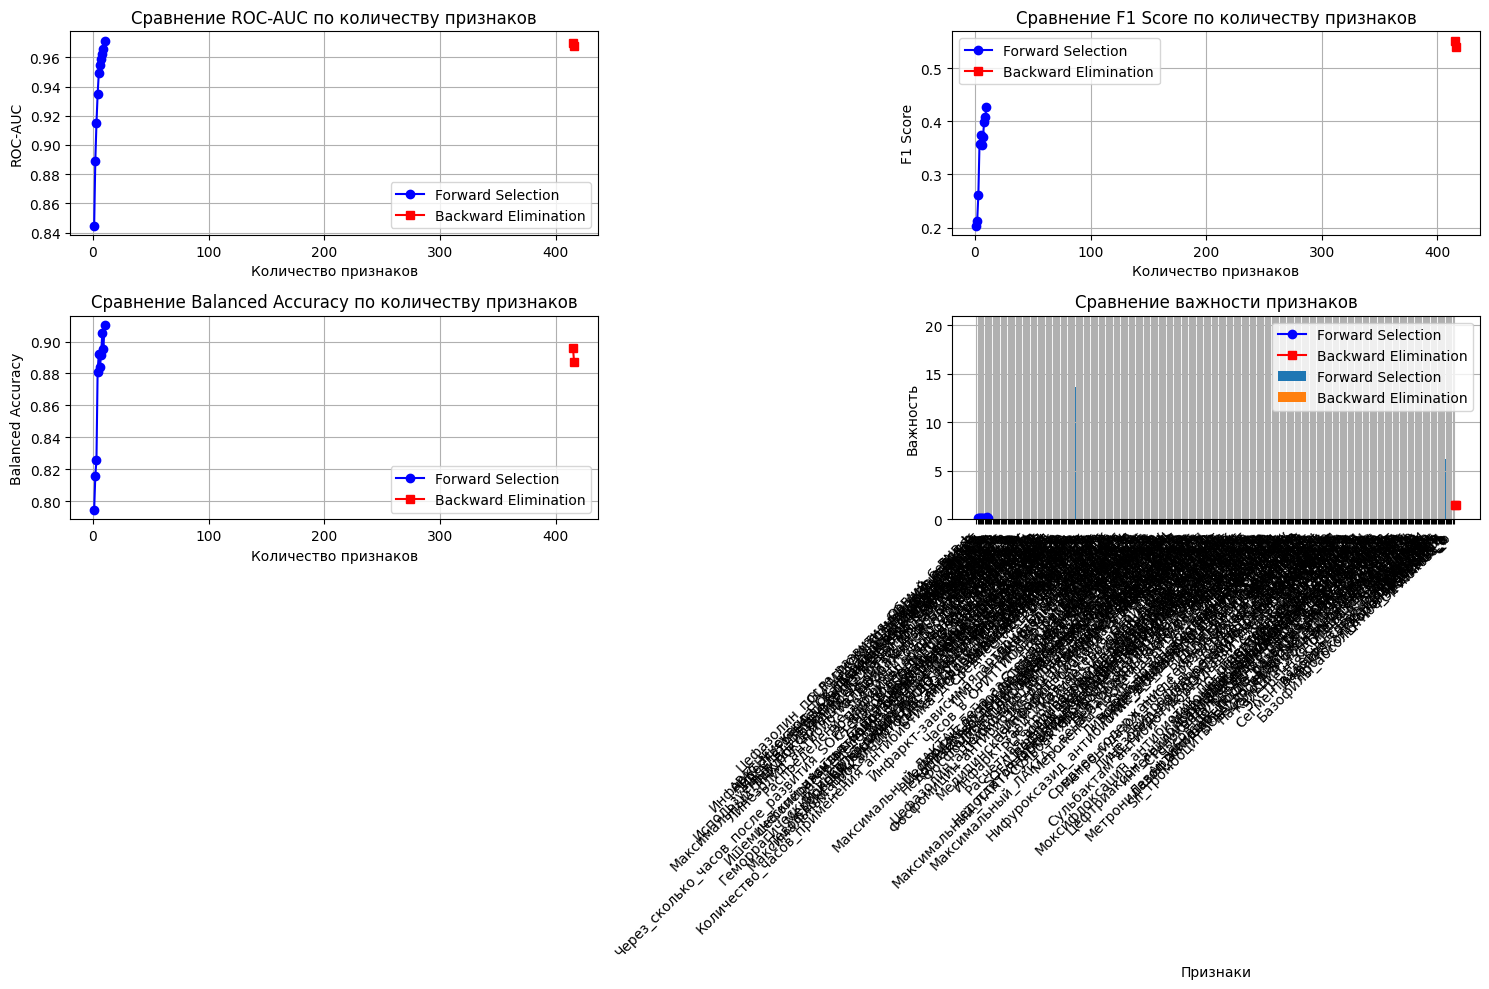

In [21]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [22]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 10 признаков) ===
По Balanced Accuracy score: 0.3600 (F1=0.9171)
По Youden's J: 0.3687


In [23]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 415 признаков) ===
По Balanced Accuracy score: 0.2700 (F1=0.9160)
По Youden's J: 0.2793



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


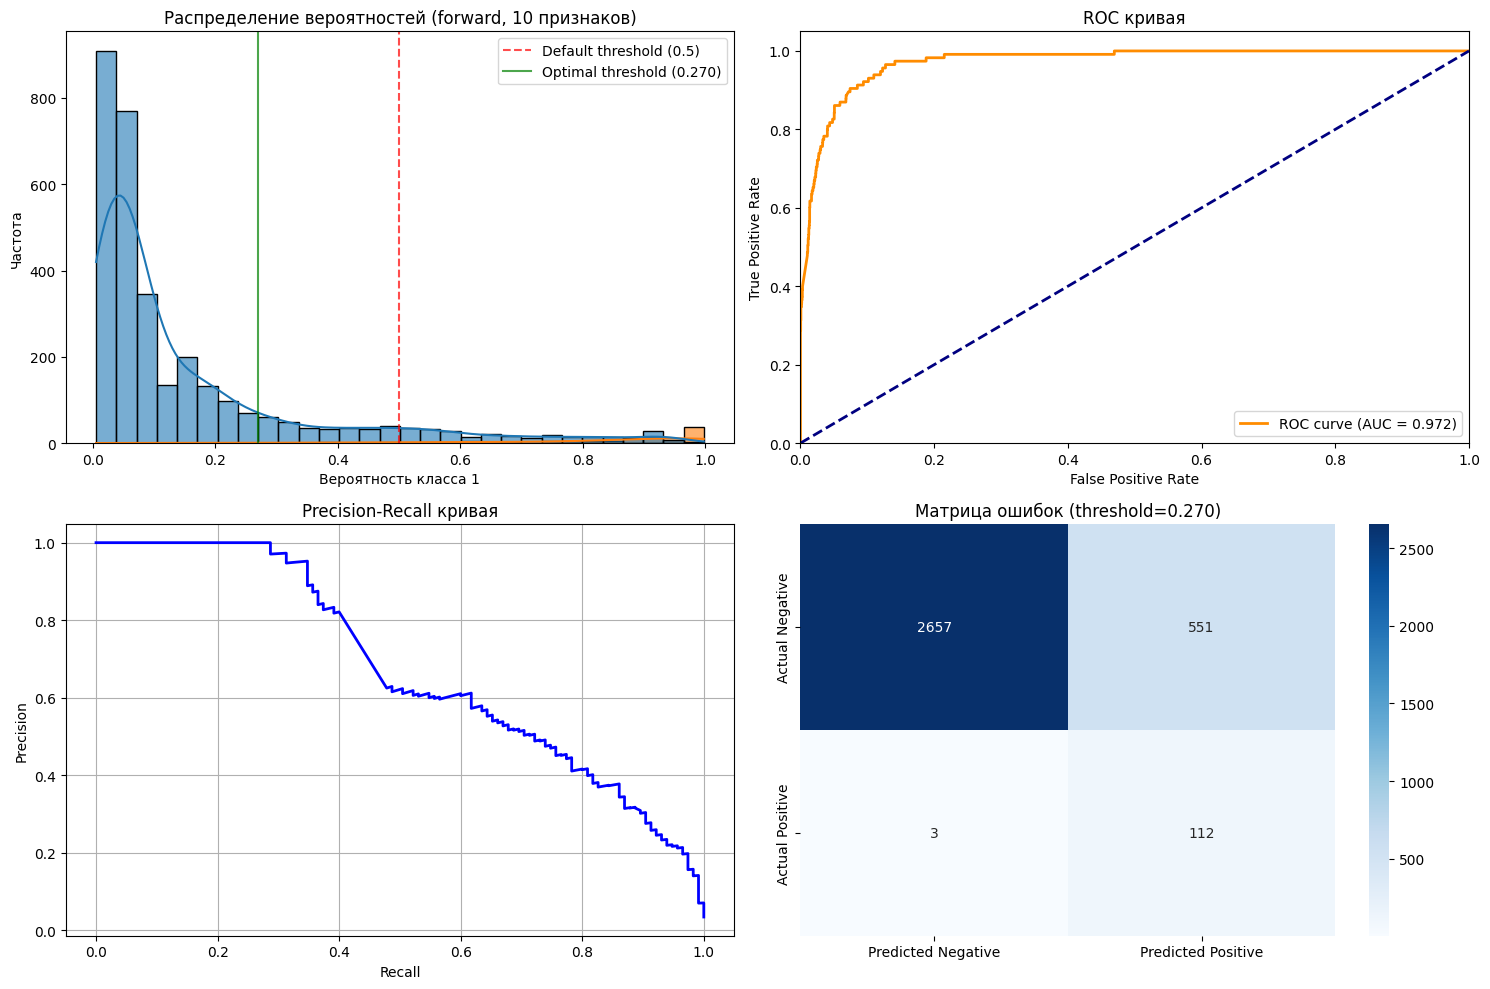

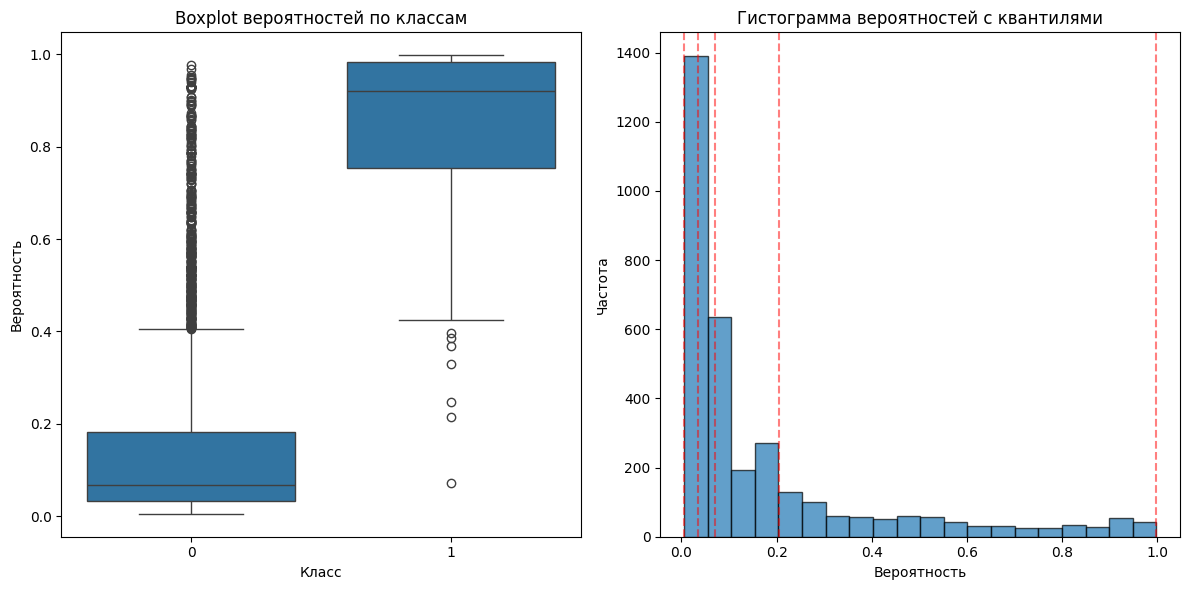

In [24]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


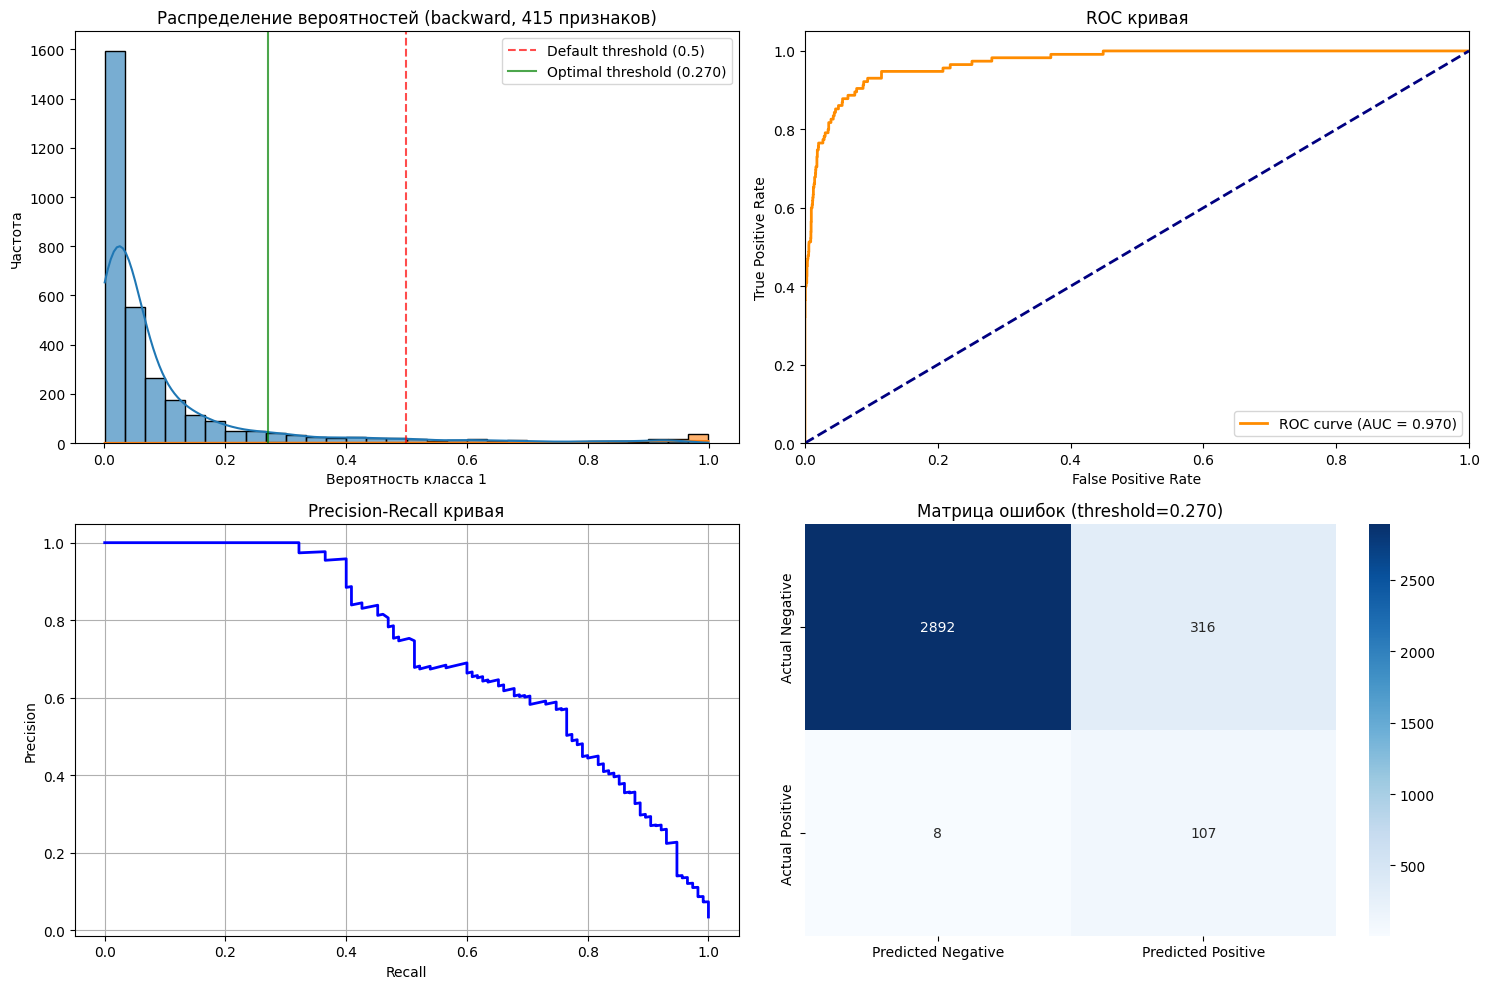

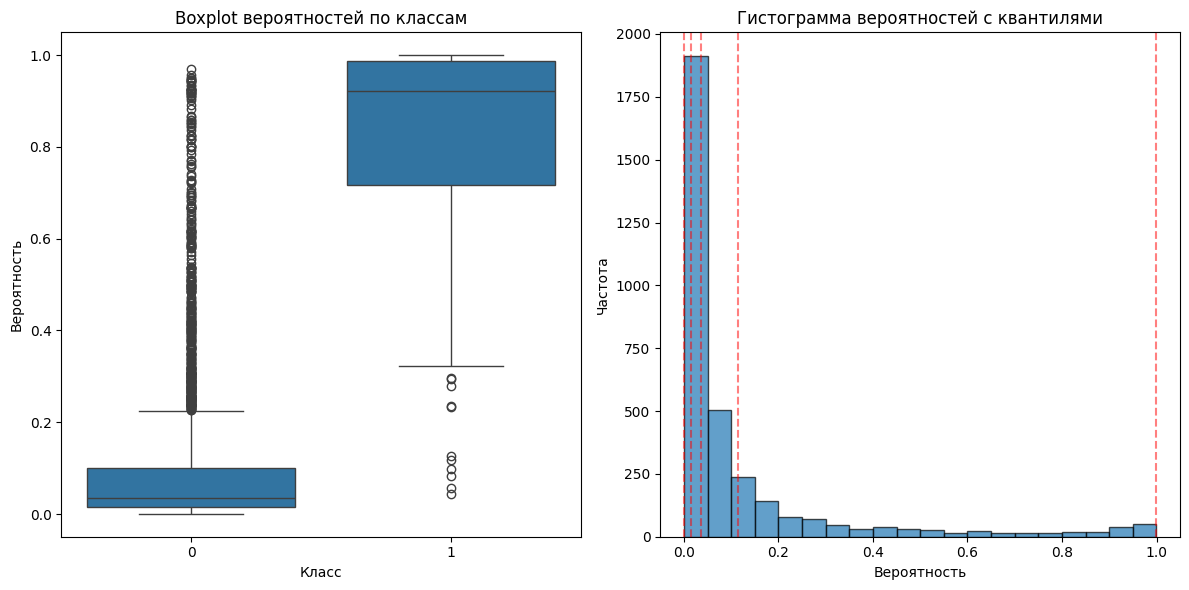

In [25]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [26]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 10
Лучшая f1: 0.4271
Признаки: ['Мочевина_a', 'Класс_ОСН_по_Killip', 'СДЛА', 'MKB', 'GRACE_Высокий_риск', 'Протокол_коронарографии', 'ФВ_lt_40', 'Калий_K_a', 'МНО_a', 'Нейтрофилы_абсолютное_значение']

Важность признаков:
  Мочевина_a: 20.0039
  MKB: 17.4008
  Нейтрофилы_абсолютное_значение: 15.5070
  СДЛА: 13.6276
  Калий_K_a: 8.0124
  Класс_ОСН_по_Killip: 7.0307
  Протокол_коронарографии: 6.1868
  GRACE_Высокий_риск: 6.0984
  МНО_a: 4.7515
  ФВ_lt_40: 1.3810
=== Лучшие признаки (backward) ===
Количество признаков: 415
Лучшая f1: 0.5517
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Инфаркт-зависимая_артерия', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'TIMI', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамне

In [27]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9715 с 10 признаками
Лучший ROC AUC (Backward): 0.9698 с 415 признаками
Оптимальный порог для бинарной классификации: 0.2700


-----------------

In [28]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [30]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


Step 1: Добавлен признак 'Мочевина_a', roc_auc: 0.8314


Step 2: Добавлен признак 'ЧСС_b', roc_auc: 0.8780


Step 3: Добавлен признак 'Apache_II', roc_auc: 0.9047


Step 4: Добавлен признак 'Моноциты_абсолютное_значение', roc_auc: 0.9264


...

Step 16: Добавлен признак 'ОНМК_иш_в_анамнезе', roc_auc: 0.9777


Step 17: Добавлен признак 'ТВ_a', roc_auc: 0.9787


Step 18: Добавлен признак 'Количество_часов_применения_антибиотика_ДО_развития_SOFA_8_и_более', roc_auc: 0.9789


  4%|▍         | 18/417 [13:16<4:54:24, 44.27s/it, roc_auc=0.9789, Features=18]

Step 19: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 18


In [ ]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


Step 1: Удален признак 'СОЭ', roc_auc: 0.9718


Step 2: Удален признак 'MKB', roc_auc: 0.9722



=== СРАВНЕНИЕ МЕТОДОВ ===


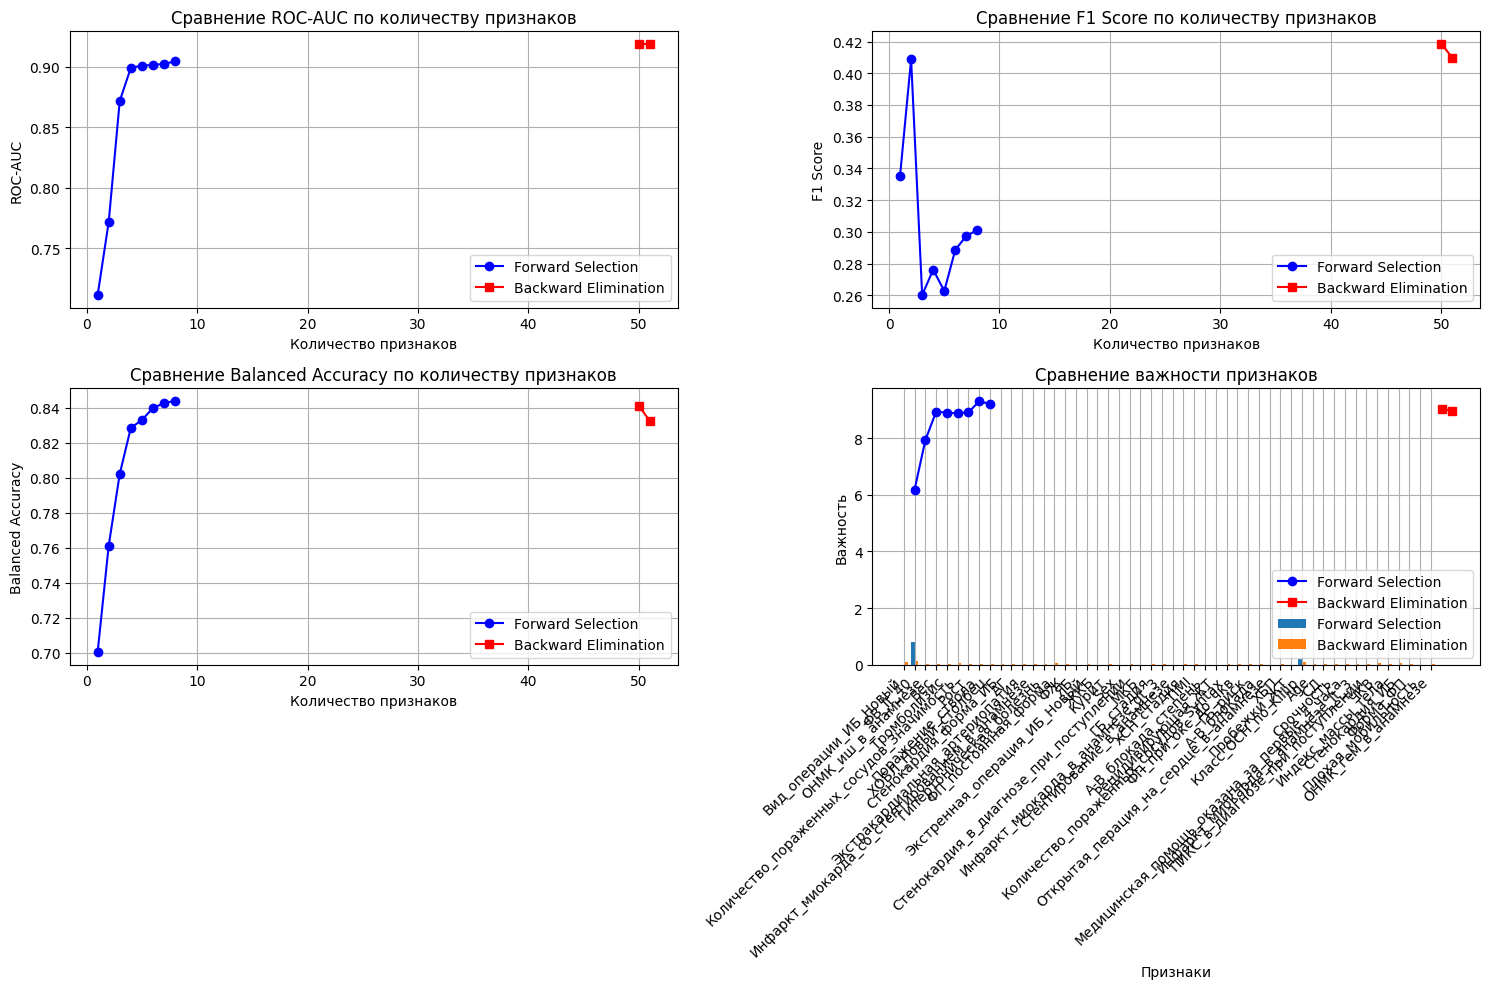

In [ ]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [ ]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 8 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.8440)
По Youden's J: 0.5092


In [ ]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 50 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.8412)
По Youden's J: 0.5091



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


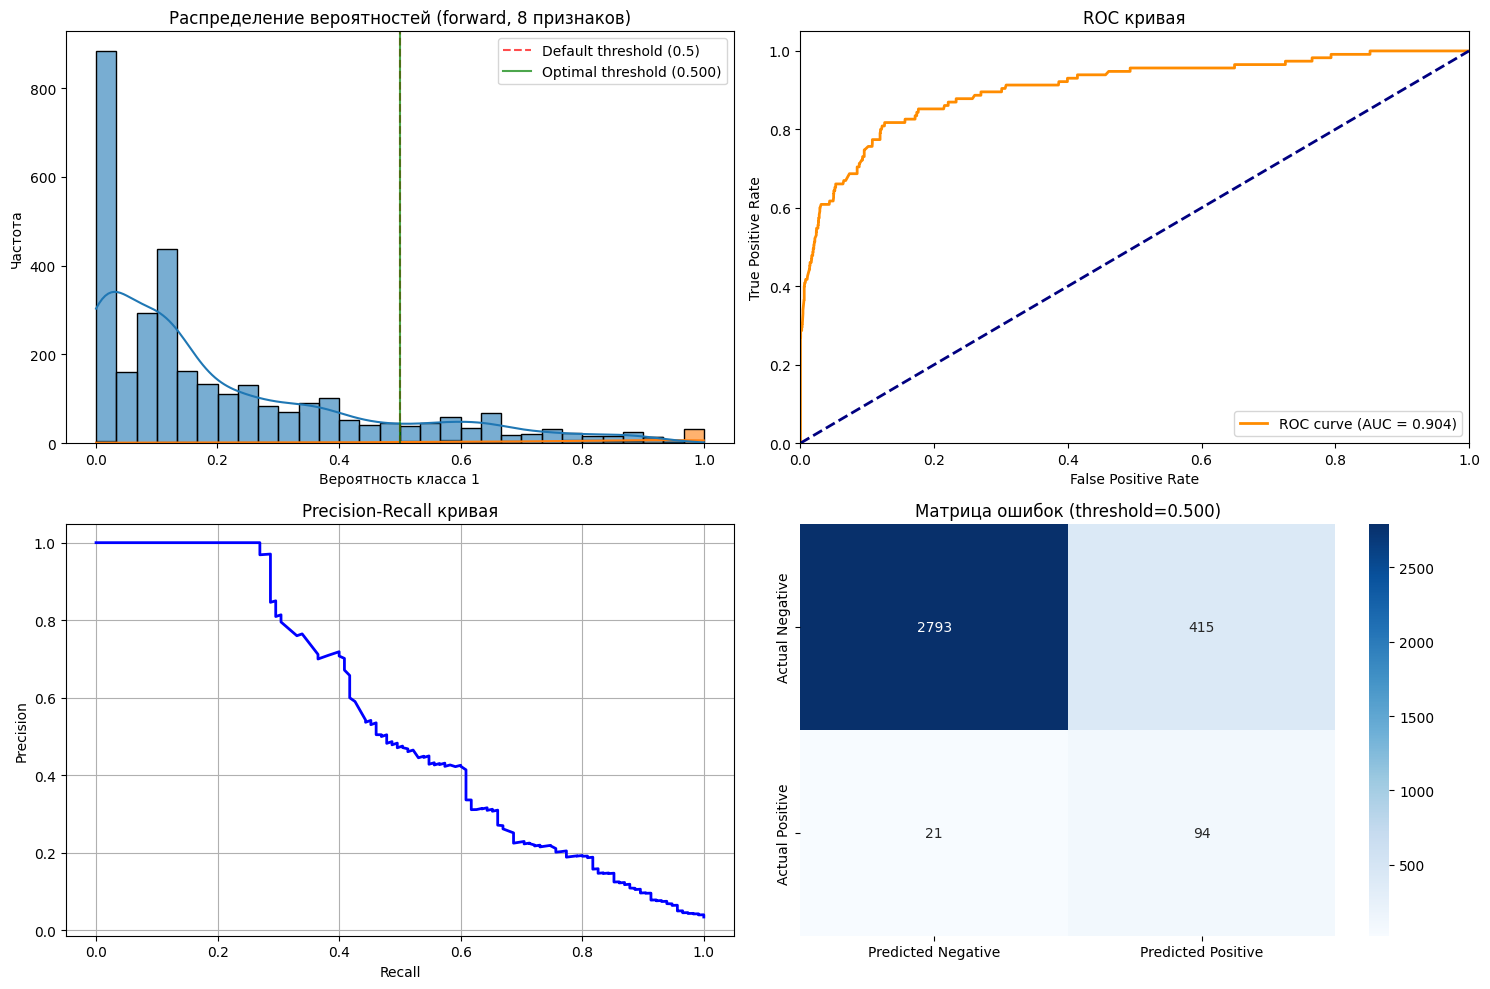

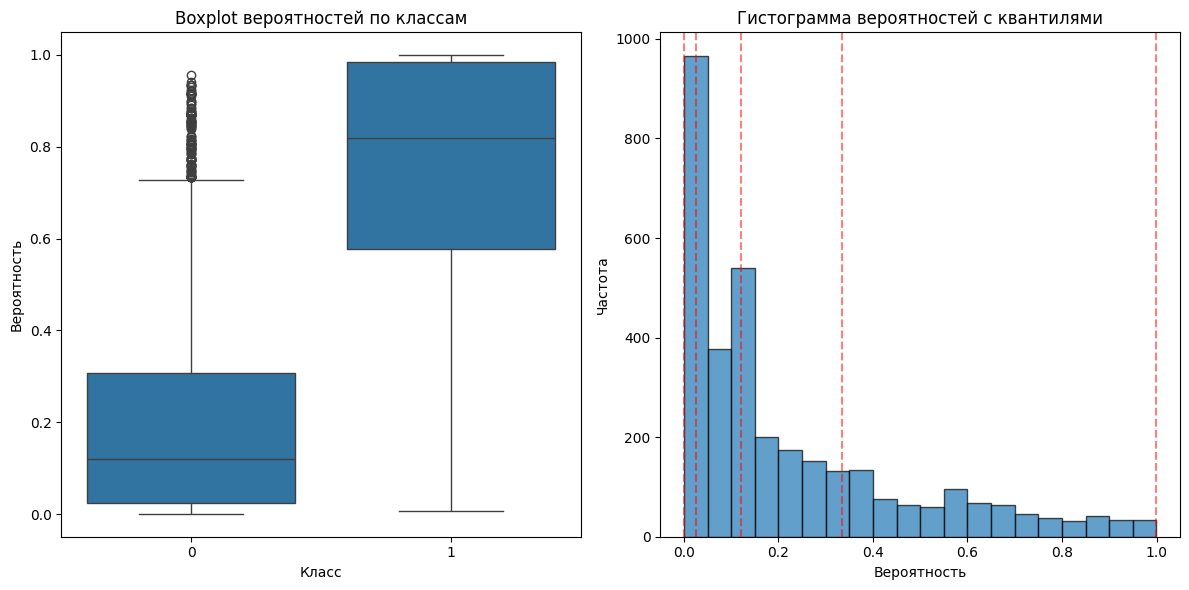

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


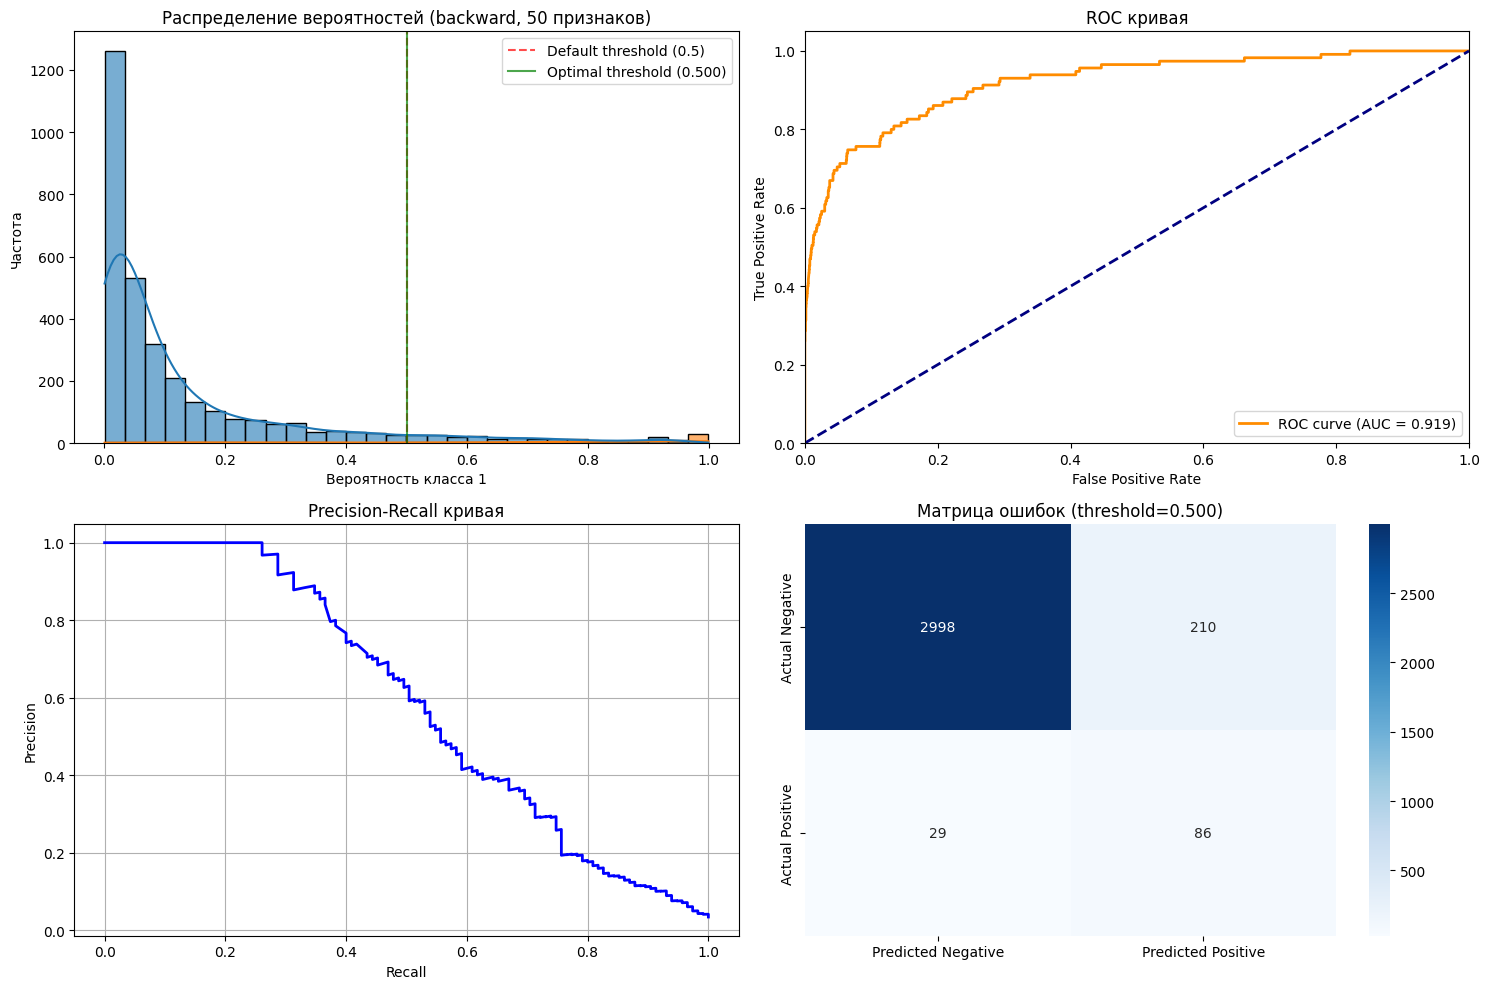

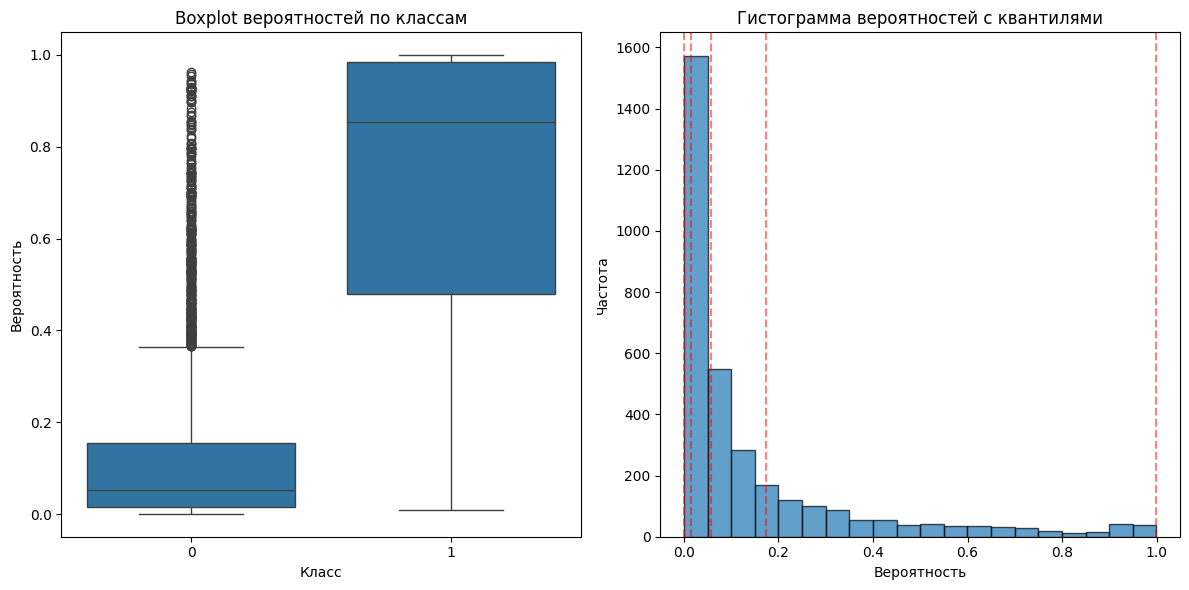

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [ ]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 2
Лучшая f1: 0.4088
Признаки: ['Класс_ОСН_по_Killip', 'ФВ_lt_40']

Важность признаков:
  ФВ_lt_40: 0.8146
  Класс_ОСН_по_Killip: 0.1854
=== Лучшие признаки (backward) ===
Количество признаков: 50
Лучшая f1: 0.4185
Признаки: ['Age', 'Sex', 'Рост', 'Вес', 'Индекс_массы_тела', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Открытая_перация_на_сердце_в_анамнезе', 'ГБ_стадия', 'ГБ_риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'ХОБЛ_Новый_столбец', 'Курит', 'Экстракардиальная_артериопатия', 'Плохая_мобильность', 'Стенокардия_ИБ', 'Стенокардия_форма_ИБ', 'Стенокардия_в_диагнозе_при_поступлении', 'ПИКС_в_диагнозе_при_поступлении', 'Форма_ФП', 'ФП_постоянная_форма', 'ФП_при_окс_до_чкв', 'ЧКВ', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax'

In [ ]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.7715 с 2 признаками
Лучший ROC AUC (Backward): 0.9187 с 50 признаками
Оптимальный порог для бинарной классификации: 0.5000


In [ ]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [ ]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

In [ ]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации


=== СРАВНЕНИЕ МЕТОДОВ ===


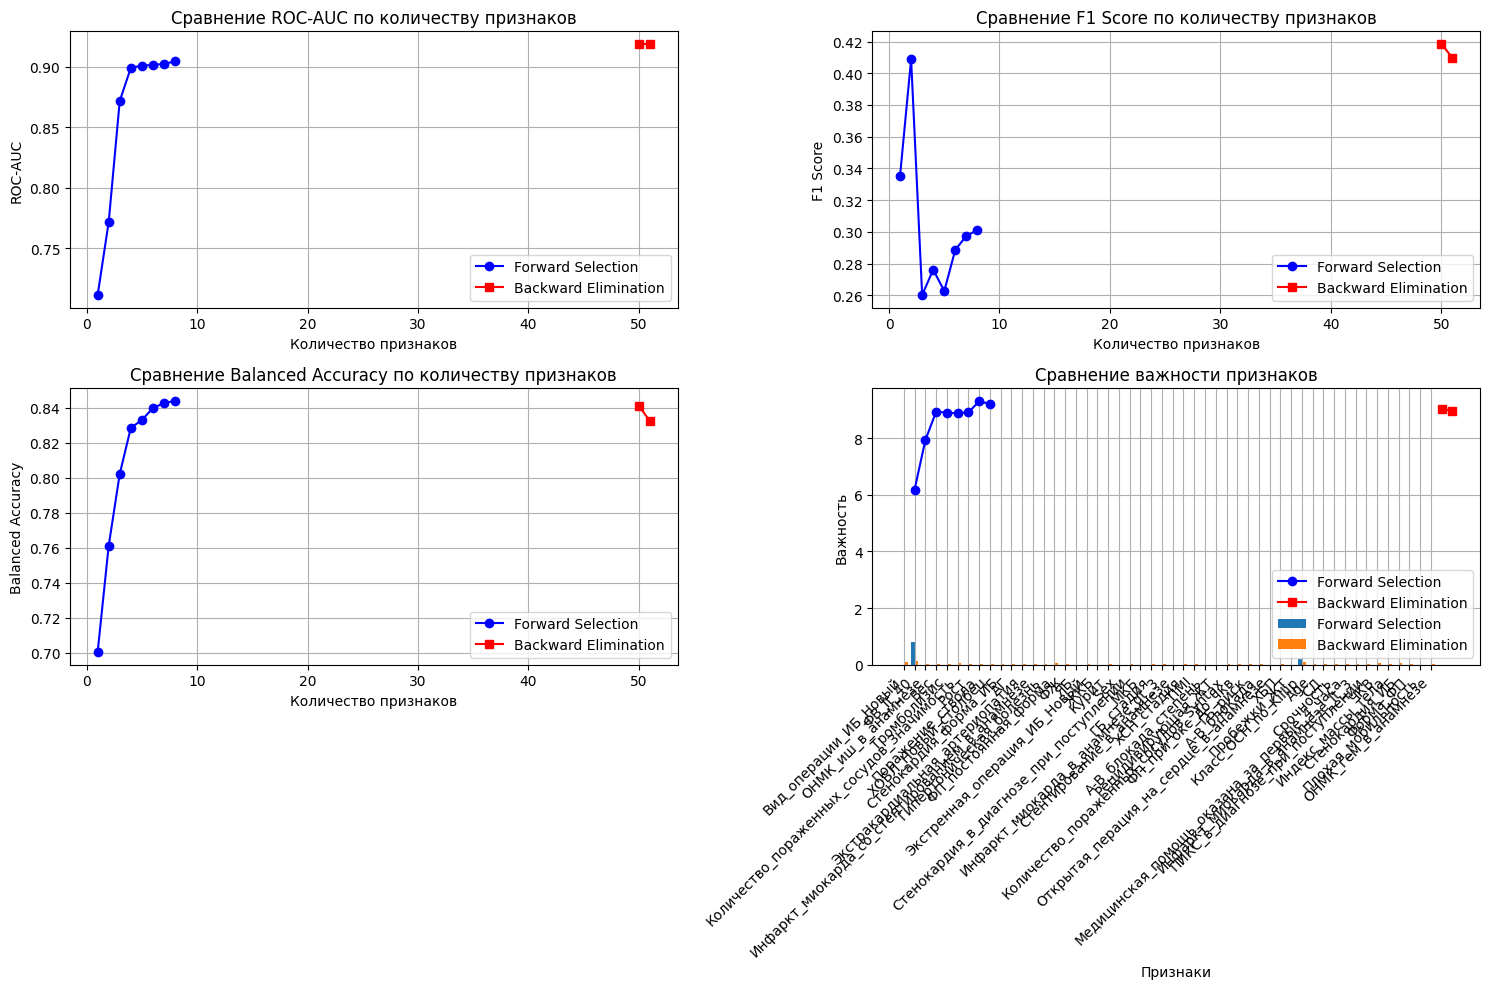

In [ ]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [ ]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 8 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.8440)
По Youden's J: 0.5092


In [ ]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 50 признаков) ===
По Balanced Accuracy score: 0.5000 (F1=0.8412)
По Youden's J: 0.5091



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


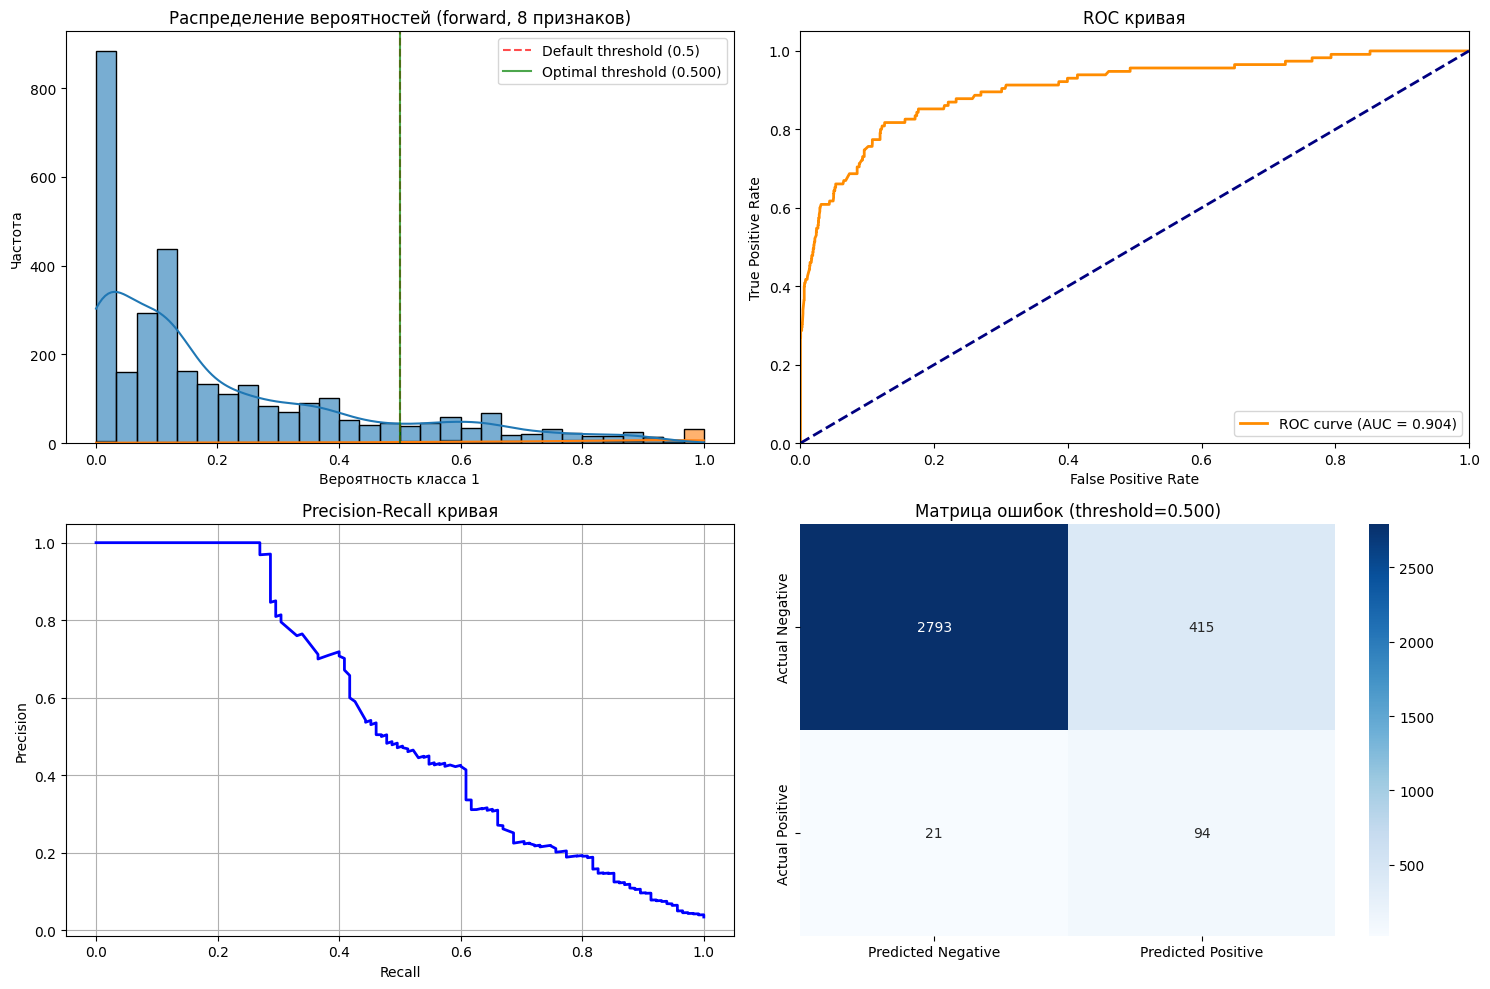

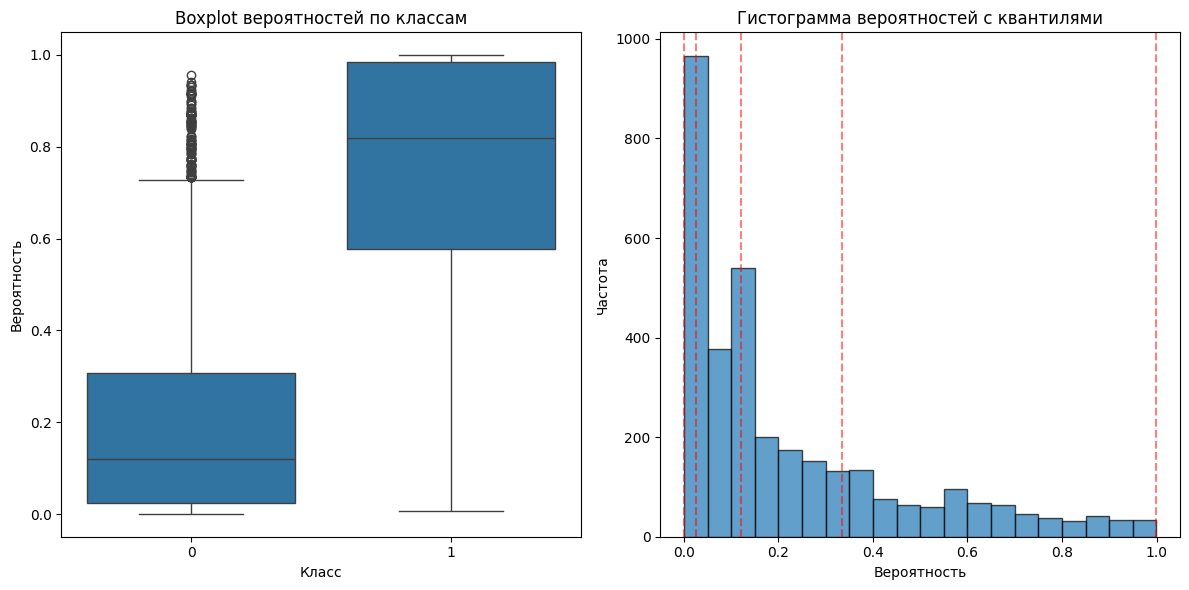

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


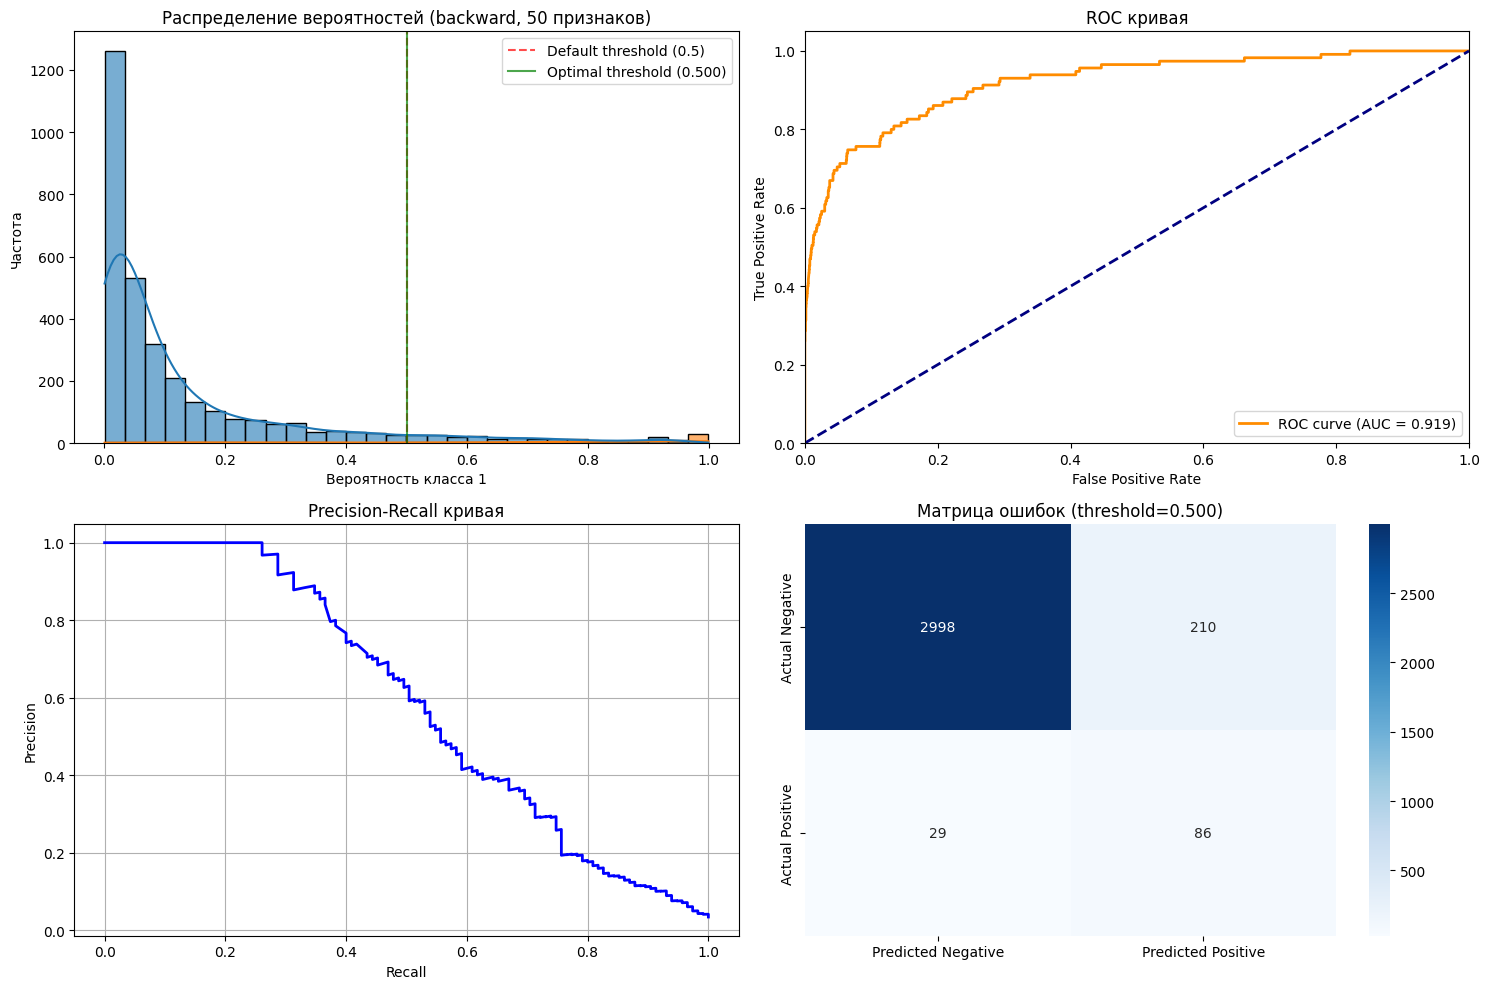

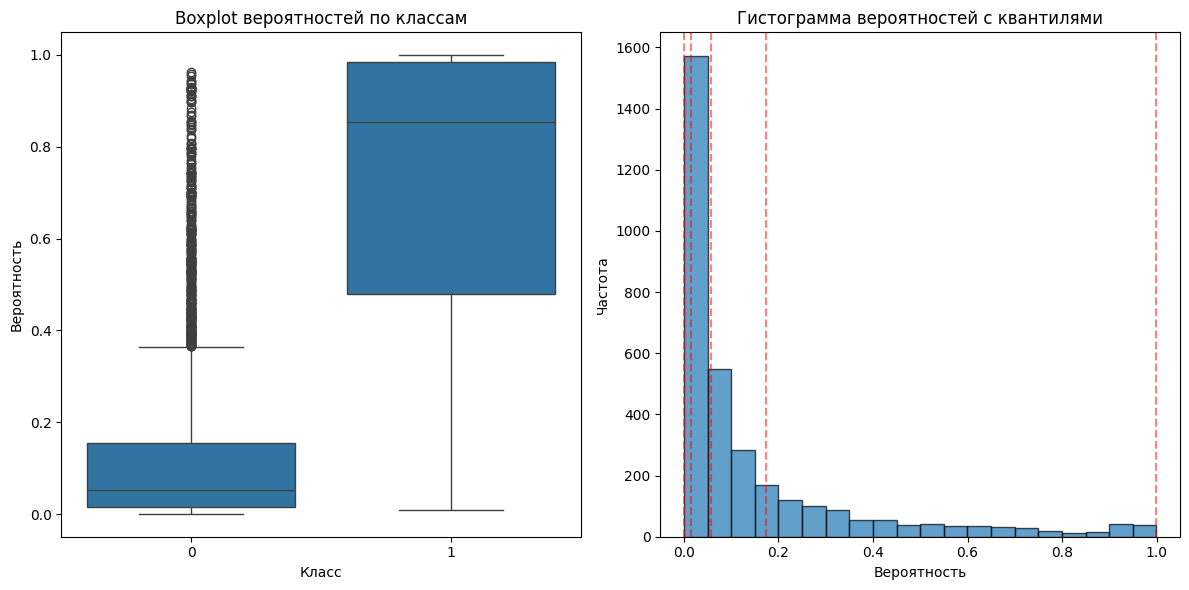

In [ ]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [ ]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 2
Лучшая f1: 0.4088
Признаки: ['Класс_ОСН_по_Killip', 'ФВ_lt_40']

Важность признаков:
  ФВ_lt_40: 0.8146
  Класс_ОСН_по_Killip: 0.1854
=== Лучшие признаки (backward) ===
Количество признаков: 50
Лучшая f1: 0.4185
Признаки: ['Age', 'Sex', 'Рост', 'Вес', 'Индекс_массы_тела', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Открытая_перация_на_сердце_в_анамнезе', 'ГБ_стадия', 'ГБ_риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'ХОБЛ_Новый_столбец', 'Курит', 'Экстракардиальная_артериопатия', 'Плохая_мобильность', 'Стенокардия_ИБ', 'Стенокардия_форма_ИБ', 'Стенокардия_в_диагнозе_при_поступлении', 'ПИКС_в_диагнозе_при_поступлении', 'Форма_ФП', 'ФП_постоянная_форма', 'ФП_при_окс_до_чкв', 'ЧКВ', 'Поражение_ствола', 'Количество_пораженных_сосудов_Syntax'

In [72]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9680 с 11 признаками
Лучший ROC AUC (Backward): 0.9646 с 392 признаками
Оптимальный порог для бинарной классификации: 0.3100
